# XGBoost Classifier Notebook (Using CRSP Data)

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
import optuna
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)
import pickle as pkl

c:\Users\jgte2\anaconda3\envs\cljc\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


##### Data Prep

In [4]:
NUM_COL = 'true_prc'
DATE_COL = 'dlycaldt'
TICKER_COL1 = 'permno'
TICKER_COL2 = 'ticker'
SPLIT_DATE = "2014-01-01"
START_BALANCE = 1000
EXIT_PROP = 1.0
LOOKBACK = 3
POSITIVE_THRESHOLD = 0.5
n_train_tickers= 1000

##### Data Prep

In [5]:
data = pd.read_csv('./data/crsp_dsf.csv')
data[DATE_COL] = data[DATE_COL].astype('datetime64[s]')
data = data.dropna(subset='dlyclose').reset_index(drop=True)
data['dlyvol'] = data['dlyvol'].fillna(0)
data['tot_shares'] = (data['dlycap'] / data['dlyprc']).round(0)
data[NUM_COL] = data['dlyclose'] * data['tot_shares'] / 1000000
data.head()

C:\Users\jgte2\AppData\Local\Temp\ipykernel_16572\846092833.py:1: DtypeWarning: Columns (28) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('./data/crsp_dsf.csv')


,permno,hdrcusip,permco,siccd,nasdissuno,yyyymmdd,sharetype,securitytype,securitysubtype,usincflg,...,dlymmcnt,dlyprcvol,dlycumfacpr,dlycumfacshr,cusip,ticker,exchangetier,shrout,tot_shares,true_prc
0,10001,36720410,7953,4925,10398,20100104,NS,EQTY,COM,Y,...,NaN,189625.0,1.0,1.0,29269V10,EGAS,NaN,4361,4361.0,0.044700
1,10002,05978R10,7954,6020,10399,20100104,NS,EQTY,COM,Y,...,27.0,86319.5,1.0,1.0,05978R10,BTFG,Q,17634,17634.0,0.054665
2,10025,00103110,7975,3081,10432,20100104,NS,EQTY,COM,Y,...,25.0,1334002.8,1.0,1.0,00103110,AEPI,Q,6852,6852.0,0.271065
3,10026,46603210,7976,2052,10433,20100104,NS,EQTY,COM,Y,...,29.0,1923931.8,1.0,1.0,46603210,JJSF,Q,18374,18374.0,0.738635
4,10028,29402E10,7978,5094,22226,20100104,NS,EQTY,COM,Y,...,NaN,5460.4,1.0,1.0,23323G10,DGSE,NaN,9834,9834.0,0.013769


In [6]:
avsp = pd.read_csv(f'./data/all_avsp_crsp_window_{LOOKBACK}.csv')
avsp[DATE_COL] = pd.to_datetime(avsp[DATE_COL])

In [7]:
added_cols = ['pos', 'neg']
avsp_cols = [TICKER_COL1, TICKER_COL2, DATE_COL]
avsp_cols.extend(added_cols)

if 'pos' in data.columns:
    data.drop(columns=added_cols, inplace=True)

data = pd.merge(left=data, right=avsp[avsp_cols],  on=[TICKER_COL1, TICKER_COL2, DATE_COL])

# Delete avsp after merge to save memory (we don't need it after this)
del avsp

In [8]:
training_tickers = pd.read_csv("./data/training_tickers.csv")

In [9]:
reg_df = data.sort_values([TICKER_COL1, TICKER_COL2, DATE_COL]).copy()

reg_df["target"] = reg_df.groupby([TICKER_COL1, TICKER_COL2])[NUM_COL].shift(-1)

reg_df[f"lag_prc_1"] = reg_df.groupby([TICKER_COL1, TICKER_COL2])[NUM_COL].shift(1)

for lag in [2, 3, 5, 10, 20]:
    reg_df[f"lag_prc_{lag}"] = reg_df[NUM_COL] / reg_df.groupby([TICKER_COL1, TICKER_COL2])[NUM_COL].shift(lag) - 1

for lag in [1, 2, 3, 5, 10]:
    reg_df[f"lag_ret_{lag}"] = reg_df.groupby([TICKER_COL1, TICKER_COL2])["dlyret"].shift(lag)

for lag in [1, 2, 3, 5, 10, 20]:
    reg_df[f"vol_pct_{lag}"] = reg_df["dlyprcvol"] / reg_df.groupby([TICKER_COL1, TICKER_COL2])["dlyprcvol"].shift(lag) - 1

for win in [5, 10, 20, 50]:
    reg_df[f"ma_{win}"] = reg_df.groupby([TICKER_COL1, TICKER_COL2])[NUM_COL].transform(lambda x: x.rolling(win).mean())

reg_df["vol_20"] = reg_df.groupby([TICKER_COL1, TICKER_COL2])["dlyret"].transform(lambda x: x.rolling(20).std())

reg_df["vol_ma_20"] = reg_df.groupby([TICKER_COL1, TICKER_COL2])["dlyprcvol"].transform(lambda x: x.rolling(20).mean())

reg_df["vol_ratio"] = reg_df["dlyprcvol"] / reg_df["vol_ma_20"]

reg_df["spread"] = reg_df["dlyask"] / reg_df["dlybid"] - 1

FEATURES = [
    "lag_prc_1", "lag_prc_2", "lag_prc_3", "lag_prc_5", "lag_prc_10", "lag_prc_20",
    "vol_pct_1", "vol_pct_2", "vol_pct_3", "vol_pct_5", "vol_pct_10", "vol_pct_20",
    "vol_ratio", "spread", "pos", "neg"
]

reg_df = reg_df[[TICKER_COL1, TICKER_COL2, DATE_COL, NUM_COL, "target"] + FEATURES].dropna().reset_index(drop=True)

ticker_set = set(map(tuple, training_tickers[[TICKER_COL1, TICKER_COL2]].to_numpy()))

mask = reg_df[[TICKER_COL1, TICKER_COL2]].apply(tuple, axis=1).isin(ticker_set)

train_df = reg_df[mask & (reg_df[DATE_COL] < SPLIT_DATE)]

test_df = reg_df[reg_df[DATE_COL] >= SPLIT_DATE]

X_train = train_df[FEATURES]
y_train = (train_df["target"] > train_df["lag_prc_1"]).astype(int)
X_train.drop(columns=["lag_prc_1"], inplace=True)

X_test = test_df[FEATURES]
y_test = (test_df["target"] > test_df["lag_prc_1"]).astype(int)
X_test.drop(columns=["lag_prc_1"], inplace=True)

C:\Users\jgte2\AppData\Local\Temp\ipykernel_16572\4268436921.py:45: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train.drop(columns=["lag_prc_1"], inplace=True)
C:\Users\jgte2\AppData\Local\Temp\ipykernel_16572\4268436921.py:49: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test.drop(columns=["lag_prc_1"], inplace=True)


##### Basline Model

In [ ]:
model = XGBClassifier(
    objective="binary:logistic",
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=29,
    n_jobs=-1,
    eval_metric="logloss"
)

model.fit(X_train, y_train)
pred_probs = model.predict_proba(X_test)[:, 1]
preds = (pred_probs >= POSITIVE_THRESHOLD).astype(int)

with open("./models/baseline_xgboost_class_model_072126_01.pkl", "wb") as f:
    pkl.dump(model, f)

In [16]:
print(f"Accuracy : {accuracy_score(y_test, preds):.4f}")
print(f"Precision: {precision_score(y_test, preds):.4f}")
print(f"Recall   : {recall_score(y_test, preds):.4f}")
print(f"F1 Score : {f1_score(y_test, preds):.4f}")
print(f"ROC AUC  : {roc_auc_score(y_test, pred_probs):.4f}")

Accuracy : 0.7137
Precision: 0.7040
Recall   : 0.7166
F1 Score : 0.7102
ROC AUC  : 0.7896


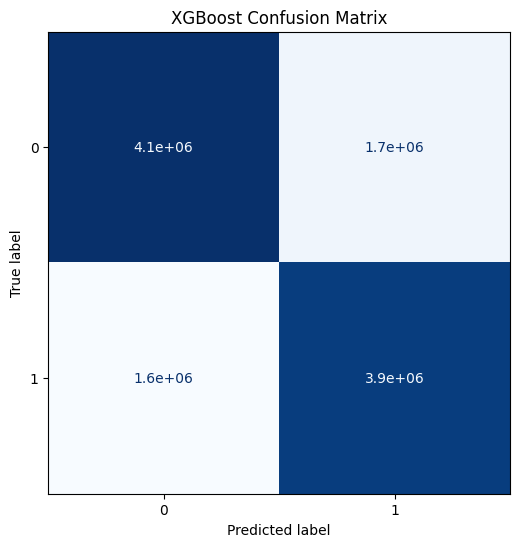

In [17]:
fig, ax = plt.subplots(figsize=(6, 6))

ConfusionMatrixDisplay.from_predictions(y_test, preds, cmap="Blues",  colorbar=False, ax=ax)

ax.set_title("XGBoost Confusion Matrix")
plt.show()

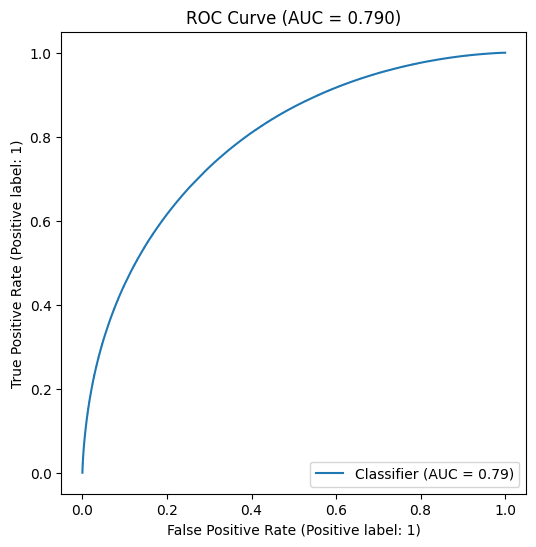

In [18]:
fig, ax = plt.subplots(figsize=(6, 6))

RocCurveDisplay.from_predictions(y_test, pred_probs, ax=ax)

auc = roc_auc_score(y_test, pred_probs)
ax.set_title(f"ROC Curve (AUC = {auc:.3f})")

plt.show()

In [19]:
preds_df = test_df[[DATE_COL, TICKER_COL1, TICKER_COL2, NUM_COL]].copy()
preds_df['pred'] = preds

##### Trading Strategy

In [8]:
def trade_strat_single(df, curr_b=1000, exit_prop=1.0, pred_col='pred'):
    ### Defaults to starting balance of 1000 and full exits
    curr_vol = 0

    returns = []

    for _, row in df.iterrows():

        pred = row[pred_col]
        num = row[NUM_COL]

        ### Buy signal
        if pred == 1:
            ### Only buy if we have balance
            ### Otherwise we will just be holding the stock
            if curr_b > 0:
                curr_vol += curr_b / num
                curr_b = 0

        ### Sell signal
        else:
            ### Only sell if we have volume to sell
            if curr_vol > 0:
                shares_sold = exit_prop * curr_vol
                curr_b += shares_sold * num
                curr_vol -= shares_sold
                
        ### Current Return of the Strategy
        ### Cash Balance + Value of Held Stock
        returns.append(curr_b + curr_vol * num)
    
    return returns

In [9]:
def trade_strat(data, tickers, curr_b=START_BALANCE, exit_prop=EXIT_PROP, pred_col='pred'):
    ret_df = pd.DataFrame()
    for t in tickers:
        df = data[(data[TICKER_COL1] == t[0]) & (data[TICKER_COL2] == t[1])].reset_index(drop=True)
        returns = trade_strat_single(df, curr_b=curr_b, exit_prop=exit_prop, pred_col=pred_col)
        start_vol = START_BALANCE / df[NUM_COL].iloc[0]
        hold_ret = start_vol * df[NUM_COL].values
        stg_df = (
            df[[TICKER_COL1, TICKER_COL2, DATE_COL]]
            .copy()
            .assign(
                strat_ret=returns,
                hold_ret=hold_ret
            )
        )
        if len(ret_df) == 0:
            ret_df = stg_df.copy()
        else:
            ret_df = pd.concat([ret_df, stg_df])
    return ret_df

In [ ]:
# filename = f"./data/xgboost_class_baseline_model_returns_072126_01.csv"
# pred_tickers = preds_df[[TICKER_COL1, TICKER_COL2]].drop_duplicates().reset_index(drop=True)
# ret_df = trade_strat(preds_df, pred_tickers.values)
# ret_df.to_csv(filename, index=False)

# ### For training returns
# pred_probs = model.predict_proba(X_train)[:, 1]
# preds = (pred_probs >= POSITIVE_THRESHOLD).astype(int)
# preds_df = train_df[[DATE_COL, TICKER_COL1, TICKER_COL2, NUM_COL]].copy()
# preds_df['pred'] = preds

# filename = f"./data/xgboost_baseline_avsp_class_model_train_returns_072126_01.csv"
# pred_tickers = preds_df[[TICKER_COL1, TICKER_COL2]].drop_duplicates().reset_index(drop=True)
# ret_df = trade_strat(preds_df, pred_tickers.values)
# ret_df.to_csv(filename, index=False)

filename = f"./data/xgboost_class_baseline_model_returns_072126_01.csv"
ret_df = pd.read_csv(filename)
ret_df[DATE_COL] = pd.to_datetime(ret_df[DATE_COL])

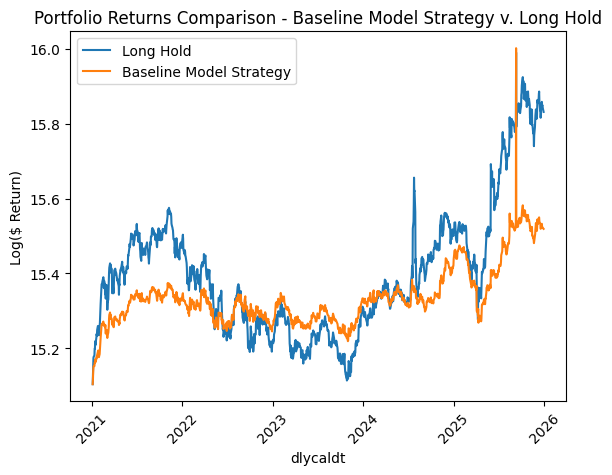

In [18]:
### There was some weird data corruption on the last day
plot_df = ret_df.groupby(by=DATE_COL).agg({"strat_ret" : "sum", "hold_ret" : "sum"}).iloc[:-1,:]

sns.lineplot(x=plot_df.index, y=np.log(plot_df['hold_ret']), label="Long Hold")
sns.lineplot(x=plot_df.index, y=np.log(plot_df['strat_ret']), label="Baseline Model Strategy")

plt.title("Portfolio Returns Comparison - Baseline Model Strategy v. Long Hold")
plt.ylabel("Log($ Return)")
plt.xticks(rotation=45)
plt.legend()
plt.show()

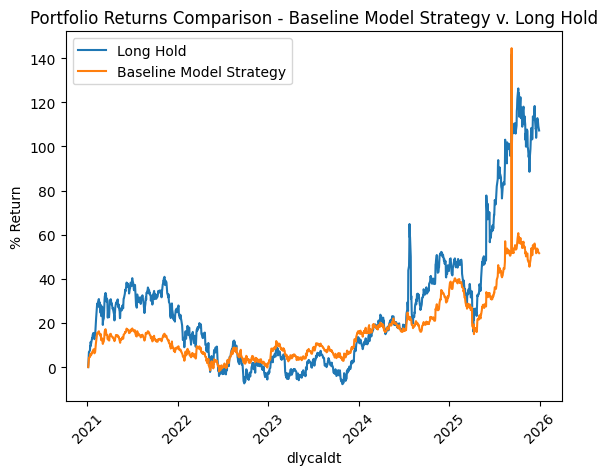

In [19]:
### There was some weird data corruption on the last day
plot_df = ret_df.groupby(by=DATE_COL).agg({"strat_ret" : "sum", "hold_ret" : "sum", TICKER_COL1 : "count"}).rename(columns={TICKER_COL1:"num_stocks"}).iloc[:-1,:]
plot_df['base_bal'] = plot_df["num_stocks"] * START_BALANCE
plot_df["strat_pct_grwth"] = (plot_df["strat_ret"] / plot_df['base_bal'] - 1) * 100
plot_df["hold_pct_grwth"] = (plot_df["hold_ret"] / plot_df['base_bal'] - 1) * 100

sns.lineplot(x=plot_df.index, y=plot_df['hold_pct_grwth'], label="Long Hold")
sns.lineplot(x=plot_df.index, y=plot_df['strat_pct_grwth'], label="Baseline Model Strategy")

plt.title("Portfolio Returns Comparison - Baseline Model Strategy v. Long Hold")
plt.ylabel("% Return")
plt.xticks(rotation=45)
plt.legend()
plt.show()

##### Model Fine-Tuning

In [10]:
### Uncomment to maximize AUC
def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 1000),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
    }

    model = XGBClassifier(
        **params,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=0,
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    pred_probs = model.predict_proba(X_test)[:, 1]

    return roc_auc_score(y_test, pred_probs)

### Uncomment to minimize FPR:

# def objective(trial):
#     params = {
#         "n_estimators": trial.suggest_int("n_estimators", 200, 1000),
#         "max_depth": trial.suggest_int("max_depth", 3, 10),
#         "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
#         "subsample": trial.suggest_float("subsample", 0.6, 1.0),
#         "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
#         "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
#     }

#     model = XGBClassifier(
#         **params,
#         objective="binary:logistic",
#         eval_metric="logloss",
#         random_state=0,
#         n_jobs=-1,
#     )

#     model.fit(X_train, y_train)

#     pred_probs = model.predict_proba(X_test)[:, 1]
#     preds = (pred_probs >= POSITIVE_THRESHOLD).astype(int)

#     tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()

#     fpr = fp / (fp + tn)

#     return fpr

In [11]:
### Uncomment if Optimizing for AOC
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30)
best_params = study.best_params
print("Best ROC AUC:", study.best_value)
print("Best Parameters:")
print(best_params)
### Uncomment if Optimizing to FPR
# study = optuna.create_study(direction="minimize")
# study.optimize(objective, n_trials=30)
# best_params = study.best_params
# print("Best FPR:", study.best_value)
# print("Best Parameters:")
# print(best_params)

[I 2026-07-15 20:12:39,766] A new study created in memory with name: no-name-0d91c72c-379e-4cbb-a6c3-8e83bf6e56c5
[I 2026-07-15 20:19:38,766] Trial 0 finished with value: 0.7759060842983124 and parameters: {'n_estimators': 918, 'max_depth': 7, 'learning_rate': 0.12786859393678401, 'subsample': 0.7828296754159587, 'colsample_bytree': 0.7879546107816323, 'min_child_weight': 2}. Best is trial 0 with value: 0.7759060842983124.
[I 2026-07-15 20:20:41,457] Trial 1 finished with value: 0.7905788587380961 and parameters: {'n_estimators': 240, 'max_depth': 3, 'learning_rate': 0.10013064321924306, 'subsample': 0.9804539632069055, 'colsample_bytree': 0.611946914542578, 'min_child_weight': 5}. Best is trial 1 with value: 0.7905788587380961.
[I 2026-07-15 20:25:05,019] Trial 2 finished with value: 0.7908769743472989 and parameters: {'n_estimators': 405, 'max_depth': 4, 'learning_rate': 0.022291078219900305, 'subsample': 0.6055952883711646, 'colsample_bytree': 0.8432099531860486, 'min_child_weight':

Best ROC AUC: 0.7914872960593609
Best Parameters:
{'n_estimators': 515, 'max_depth': 6, 'learning_rate': 0.015493676821132512, 'subsample': 0.6923553160969655, 'colsample_bytree': 0.703205724752997, 'min_child_weight': 7}


In [ ]:
final_model = XGBClassifier(
    **best_params,
    random_state=29,
    n_jobs=-1
)

final_model.fit(X_train, y_train)
final_pred_probs = final_model.predict(X_test)
final_preds = (final_pred_probs >= POSITIVE_THRESHOLD).astype(int)
with open("./models/tuned_xgboost_class_model_072126_01.pkl", "wb") as f:
    pkl.dump(final_model, f)

In [13]:
try:
    preds_df['final_pred'] = final_preds
except:
    preds_df = test_df[[DATE_COL, TICKER_COL1, TICKER_COL2, NUM_COL, "target"]].copy()
    preds_df['final_pred'] = final_preds

In [11]:
filename = f"./data/xgboost_class_tuned_model_returns_072126_01.csv"
# pred_tickers = preds_df[[TICKER_COL1, TICKER_COL2]].drop_duplicates().reset_index(drop=True)
# ret_df = trade_strat(preds_df, pred_tickers.values, pred_col='final_pred')
# ret_df.to_csv(filename, index=False)

ret_df = pd.read_csv(filename)
ret_df[DATE_COL] = pd.to_datetime(ret_df[DATE_COL])

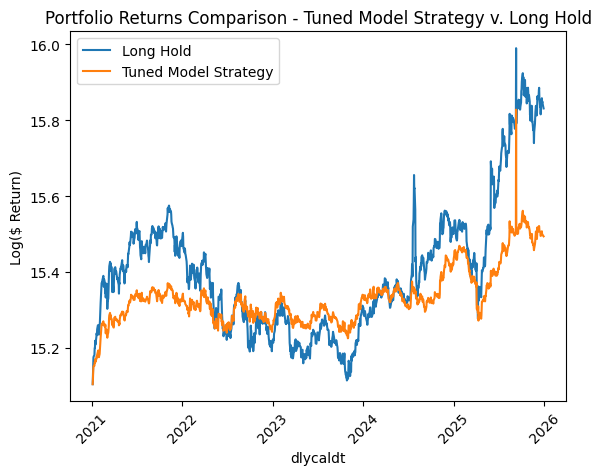

In [12]:
### There was some weird data corruption on the last day
plot_df = ret_df.groupby(by=DATE_COL).agg({"strat_ret" : "sum", "hold_ret" : "sum"}).iloc[:-1,:]

sns.lineplot(x=plot_df.index, y=np.log(plot_df['hold_ret']), label="Long Hold")
sns.lineplot(x=plot_df.index, y=np.log(plot_df['strat_ret']), label="Tuned Model Strategy")

plt.title("Portfolio Returns Comparison - Tuned Model Strategy v. Long Hold")
plt.ylabel("Log($ Return)")
plt.xticks(rotation=45)
plt.legend()
plt.show()

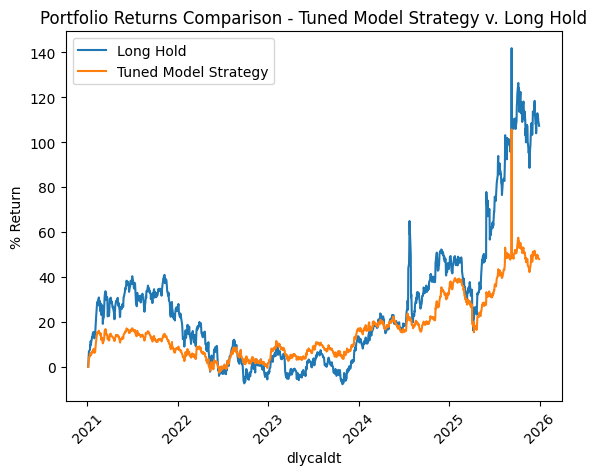

In [13]:
### There was some weird data corruption on the last day
plot_df = ret_df.groupby(by=DATE_COL).agg({"strat_ret" : "sum", "hold_ret" : "sum", TICKER_COL1 : "count"}).rename(columns={TICKER_COL1:"num_stocks"}).iloc[:-1,:]
plot_df['base_bal'] = plot_df["num_stocks"] * START_BALANCE
plot_df["strat_pct_grwth"] = (plot_df["strat_ret"] / plot_df['base_bal'] - 1) * 100
plot_df["hold_pct_grwth"] = (plot_df["hold_ret"] / plot_df['base_bal'] - 1) * 100

sns.lineplot(x=plot_df.index, y=plot_df['hold_pct_grwth'], label="Long Hold")
sns.lineplot(x=plot_df.index, y=plot_df['strat_pct_grwth'], label="Tuned Model Strategy")

plt.title("Portfolio Returns Comparison - Tuned Model Strategy v. Long Hold")
plt.ylabel("% Return")
plt.xticks(rotation=45)
plt.legend()
plt.show()

Major spike and crash in 2025 was due to the **OCTO** price spike in Sept of that year.

#### Get Trading Signals

In [ ]:
with open("./models/tuned_xgboost_class_model_072126_01.pkl", "rb") as f:
    model = pkl.load(f)

### For train data
pred_probs = model.predict_proba(X_train)[:, 1]
preds = (pred_probs >= POSITIVE_THRESHOLD).astype(int)

preds_df = train_df[[DATE_COL, TICKER_COL1, TICKER_COL2, NUM_COL, "target"]].copy()
preds_df['pred'] = preds
preds_df['signal'] = preds
preds_df.to_csv("./data/xgboost_tuned_class_model_train_preds_072126_01.csv", index=False)

### For test data
pred_probs = model.predict_proba(X_test)[:, 1]
preds = (pred_probs >= POSITIVE_THRESHOLD).astype(int)
preds_df = test_df[[DATE_COL, TICKER_COL1, TICKER_COL2, NUM_COL, "target"]].copy()
preds_df['pred'] = preds
preds_df['signal'] = preds
preds_df.to_csv("./data/xgboost_tuned_class_model_test_preds_072126_01.csv", index=False)

In [11]:
preds_df

,dlycaldt,permno,ticker,true_prc,target,pred,signal
983,2014-01-02,10001,EGAS,0.084034,0.085497,1,1
984,2014-01-03,10001,EGAS,0.085497,0.087170,1,1
985,2014-01-06,10001,EGAS,0.087170,0.091664,1,1
986,2014-01-07,10001,EGAS,0.091664,0.093650,1,1
987,2014-01-08,10001,EGAS,0.093650,0.095218,1,1
...,...,...,...,...,...,...,...
14860688,2025-12-23,93436,TSLA,1614.884674,1614.352543,0,0
14860689,2025-12-24,93436,TSLA,1614.352543,1580.395931,1,1
14860690,2025-12-26,93436,TSLA,1580.395931,1528.679445,0,0
14860691,2025-12-29,93436,TSLA,1528.679445,1511.351928,0,0
